# 03 — Model & Feature Selection

This notebook finds the **best-performing combination of model + feature set** using the canonical feature table created in `02_feature_engineering.ipynb`.

The key idea is simple:

> **Different models may perform best with different groups of features, so we evaluate model choice and feature-set choice together.**

### Objectives

1. Compare several model families instead of assuming the earlier project winner is still best after the feature-engineering cleanup.

2. Compare the same models across several meaningful feature sets created from the reusable feature families in `feature_sets.py`.

3. Identify the **best feature set for each model**.

4. Rank the strongest **model + feature-set combinations** using the same validation method and the same MAE metric.

5. Shortlist the best configurations to carry into the next stage, where we will test optional cluster features and later final tuning / ensembles.

### Methodology

**5 models** are selected:
- **Ridge** — regularized linear model; useful when many features are correlated.
- **ElasticNet** — linear model with both L1 and L2 regularization; can shrink weaker features more aggressively.
- **Random Forest** — nonlinear tree ensemble; useful for testing whether interactions and nonlinear relationships improve prediction.
- **HistGradientBoosting** — nonlinear boosting model; useful for capturing more complex relationships than linear models.
- **LightGBM** - gradient-boosted decision-tree model optimized for tabular data; useful for testing whether a more flexible nonlinear boosting approach can capture interactions that linear models and sklearn HGB may miss.

Each model is tested against **8 reusable feature sets** from `feature_sets.py`:
- `core`
- `core_bat`
- `core_pitch`
- `core_bat_pitch`
- `core_bat_pitch_field`
- `all_domain`
- `raw`
- `all_domain_raw`

This produces:

**5 models × 8 feature sets = 40 model–feature combinations**

Every combination is evaluated using the **same 5-fold GroupKFold split by season (`yearID`)** and the same metric:

**Mean Absolute Error (MAE) in total season wins**

This creates a fair comparison and allow assessments like:
- Ridge works best with a broader engineered feature set;
- HGB prefers a smaller or different set;
- raw totals still add value;
- fielding or context features actually improve prediction.

### Outputs

Write to `outputs/model_selection/`:

- `03_model_feature_results.csv`  
  Full results for all 32 model–feature combinations, including mean MAE, fold variation, and feature count.

- `03_model_shortlist.csv`  
  The best feature set for each model, ranked so the strongest configurations can be carried forward.

### Decision made at the end of this notebook
- The strongest **model + its preferred feature set** combinations.
- This is important because feature usefulness is model-dependent.

### Out-of-scope for this notebook
- add KMeans / cluster features;
- perform heavy hyperparameter tuning;
- test ensembles;
- train the final submission model.

Those steps come after we know which individual model–feature combinations are worth keeping.

## 1. Setup and load feature-engineered data

This notebook reads the canonical output from `02_feature_engineering`:

- `data/processed/train_fe.csv`
- `data/processed/pred_fe.csv`



In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from moneyball import project_config as cfg
from moneyball import feature_sets as fs
from moneyball import model_factory as mf

# Shared notebook settings and output folders.
cfg.configure_notebook()
cfg.ensure_project_dirs()

TRAIN_FE_PATH  = cfg.TRAIN_FE_PATH
PRED_FE_PATH   = cfg.PRED_FE_PATH
RESULT_PATH    = cfg.MODEL_RESULT_PATH
SHORTLIST_PATH = cfg.MODEL_SHORTLIST_PATH

print(f"Train FE     : {TRAIN_FE_PATH}")
print(f"Prediction   : {PRED_FE_PATH}")
print(f"Results path : {RESULT_PATH}")

Train FE     : /home/shpang/devs/ntu/projects/baseball_v2/data/processed/train_fe.csv
Prediction   : /home/shpang/devs/ntu/projects/baseball_v2/data/processed/pred_fe.csv
Results path : /home/shpang/devs/ntu/projects/baseball_v2/outputs/model_selection/03_model_feature_results.csv


In [3]:
train_fe = pd.read_csv(TRAIN_FE_PATH)
pred_fe = pd.read_csv(PRED_FE_PATH)

print("Train shape :", train_fe.shape)
print("Pred shape  :", pred_fe.shape)

# Basic contract with 02. If these fail, fix 02 rather than patching around
# the problem here.
assert "target_W" in train_fe.columns
assert "target_W_pct" in train_fe.columns
assert "target_W" not in pred_fe.columns
assert "target_W_pct" not in pred_fe.columns
assert "meta_yearID" in train_fe.columns
assert "season_G" in train_fe.columns

display(train_fe.head(3))

Train shape : (1812, 78)
Pred shape  : (453, 76)


,meta_ID,meta_yearID,meta_teamID,meta_franchID,ctx_mlb_rpg,ctx_era_1,ctx_era_2,ctx_era_3,ctx_era_4,ctx_era_5,ctx_era_6,ctx_era_7,ctx_era_8,ctx_decade_1910,ctx_decade_1920,ctx_decade_1930,ctx_decade_1940,ctx_decade_1950,ctx_decade_1960,ctx_decade_1970,ctx_decade_1980,ctx_decade_1990,ctx_decade_2000,ctx_decade_2010,raw_R,raw_RA,raw_AB,raw_H,raw_2B,raw_3B,raw_HR,raw_BB,raw_SO,raw_SB,raw_ER,raw_CG,raw_SHO,raw_SV,raw_IPouts,raw_HA,raw_HRA,raw_BBA,raw_SOA,raw_E,raw_DP,season_G,core_R_pg,core_RA_pg,core_RDiff_pg,core_Pythag_win_pct,core_R_adj,core_RA_adj,core_RDiff_adj,bat_AVG,bat_OBP_approx,bat_SLG,bat_OPS_approx,bat_ISO,bat_HR_per_AB,bat_BB_rate_approx,bat_SO_rate_approx,bat_XBH_per_H,bat_SB_per_onbase_approx,pitch_ERA,pitch_WHIP,pitch_K_BB,pitch_K9,pitch_BB9,pitch_H9,pitch_HR9,pitch_CG_pg,pitch_SHO_pg,pitch_SV_pg,field_FP,field_E_pg,field_DP_pg,target_W,target_W_pct
0,317,1935,BOS,BOS,4.864690,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,718,732,5288,1458,281,63,69,609,470.0,91,619,82,6,11,4128,1520,67,520,470,190,136.0,154.0,4.662338,4.753247,-0.090909,0.491166,0.958404,0.977091,-0.018688,0.275719,0.350517,0.391831,0.742348,0.116112,0.013048,0.103273,0.079702,0.283265,0.044025,4.05,1.482558,0.903846,3.074128,3.401163,9.941860,0.438227,0.532468,0.038961,0.071429,0.969,1.233766,0.883117,78.0,0.506494
1,2162,1993,TEX,TEX,4.597620,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,835,751,5510,1472,284,39,181,483,984.0,113,684,20,6,45,4314,1476,144,562,957,130,145.0,162.0,5.154321,4.635802,0.518519,0.548355,1.121085,1.008305,0.112780,0.267151,0.326214,0.431397,0.757611,0.164247,0.032849,0.080594,0.164192,0.342391,0.057801,4.28,1.417246,1.702847,5.989569,3.517385,9.237830,0.901252,0.123457,0.037037,0.277778,0.979,0.802469,0.895062,86.0,0.530864
2,1895,2016,SEA,SEA,4.477759,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,768,707,5583,1446,251,17,223,506,1288.0,56,647,2,8,49,4371,1410,213,460,1318,89,158.0,162.0,4.740741,4.364198,0.376543,0.537790,1.058731,0.974639,0.084092,0.259001,0.320578,0.429876,0.750455,0.170876,0.039943,0.083101,0.211529,0.339557,0.028689,4.00,1.283459,2.865217,8.141386,2.841455,8.709677,1.315717,0.012346,0.049383,0.302469,0.985,0.549383,0.975309,86.0,0.530864


## 2. Load reusable feature families and feature sets

The feature families and the standard 8 benchmark combinations are defined centrally in:

`src/moneyball/feature_sets.py`

### Feature families

| Family | Meaning |
|---|---|
| `season_` | season length (`G`) |
| `core_` | high-level run production / prevention and Pythagorean features |
| `bat_` | batting quality and efficiency |
| `pitch_` | pitching quality and efficiency |
| `field_` | fielding measures |
| `ctx_` | league / era / decade context |
| `raw_` | original counting statistics retained for controlled comparison |

### Decision

We test feature **families first**, not every possible subset of individual columns.

### Reasoning

With dozens of features, brute-force subset search would be both expensive and easy to overfit. These families have baseball meaning, so the comparison remains interpretable.

In [4]:
# Load the feature families and the 8 standard benchmark sets from the
# shared module. 03 should consume these definitions, not own them.

FEATURE_FAMILIES = fs.get_feature_families(train_fe)
FEATURE_SETS = fs.get_candidate_feature_sets(train_fe)

# Validate the train/pred contract before any model is fitted.
# This catches missing prediction columns, accidental target leakage,
# and duplicate columns in a feature set.
fs.validate_feature_sets(
    train_fe,
    pred_fe,
    FEATURE_SETS,
)

family_summary = pd.DataFrame(
    {
        "family": name,
        "n_features": len(cols),
        "example_features": ", ".join(cols[:5]),
    }
    for name, cols in FEATURE_FAMILIES.items()
)

print("Feature families")
display(family_summary)

print("Feature-set validation passed.")

Feature families


,family,n_features,example_features
0,season,1,season_G
1,core,7,"core_R_pg, core_RA_pg, core_RDiff_pg, core_Pyt..."
2,bat,10,"bat_AVG, bat_OBP_approx, bat_SLG, bat_OPS_appr..."
3,pitch,10,"pitch_ERA, pitch_WHIP, pitch_K_BB, pitch_K9, p..."
4,field,3,"field_FP, field_E_pg, field_DP_pg"
5,ctx,20,"ctx_mlb_rpg, ctx_era_1, ctx_era_2, ctx_era_3, ..."
6,raw,21,"raw_R, raw_RA, raw_AB, raw_H, raw_2B"


Feature-set validation passed.


## 3. Review 8 benchmark feature sets

The combinations are deliberately **purposeful rather than exhaustive**.

Assessments include:
- Are the core baseball features enough?
- Does batting add signal?
- Does pitching add signal?
- Do batting and pitching work better together?
- Does fielding add anything once offense and pitching are present?
- Does league / era context help?
- Can the original raw totals compete with engineered rates?
- Does combining raw and engineered features help, or mostly add redundancy?

`season_G` is included by the shared definitions because the primary target is **total season wins (`W`)**.

In [5]:
# The family composition comes directly from feature_sets.py.
# Showing it here makes the experiment easy to audit without duplicating
# the actual definitions in this notebook.

feature_set_summary = pd.DataFrame(
    {
        "feature_set": set_name,
        "families": " + ".join(
            fs.DEFAULT_FEATURE_SET_DEFINITIONS[set_name]
        ),
        "n_features": len(columns),
    }
    for set_name, columns in FEATURE_SETS.items()
).sort_values("n_features")

display(feature_set_summary)

,feature_set,families,n_features
0,core,season + core,8
1,core_bat,season + core + bat,18
2,core_pitch,season + core + pitch,18
6,raw,season + raw,22
3,core_bat_pitch,season + core + bat + pitch,28
4,core_bat_pitch_field,season + core + bat + pitch + field,31
5,all_domain,season + core + bat + pitch + field + ctx,51
7,all_domain_raw,season + core + bat + pitch + field + ctx + raw,72


In [6]:
# Guard against accidental leakage or a train/pred schema mismatch.
# A candidate model feature must exist in both datasets and must never be a
# metadata or target column.

for set_name, features in FEATURE_SETS.items():
    assert len(features) == len(set(features)), f"Duplicates in {set_name}"

    missing_in_pred = sorted(set(features) - set(pred_fe.columns))
    assert not missing_in_pred, (
        f"{set_name} contains features missing from prediction data: "
        f"{missing_in_pred}"
    )

    forbidden = [
        c for c in features
        if c.startswith("meta_") or c.startswith("target_")
    ]
    assert not forbidden, f"Leakage columns in {set_name}: {forbidden}"

print("Feature-set checks passed.")

Feature-set checks passed.


In [7]:
# Final lightweight sanity check for the benchmark design.
# We expect the shared module to provide exactly the 8 standard feature sets
# described at the top of this notebook.

assert len(FEATURE_SETS) == 8, (
    f"Expected 8 benchmark feature sets, found {len(FEATURE_SETS)}."
)

print("Benchmark feature sets:", list(FEATURE_SETS))
print("Total feature sets     :", len(FEATURE_SETS))

Benchmark feature sets: ['core', 'core_bat', 'core_pitch', 'core_bat_pitch', 'core_bat_pitch_field', 'all_domain', 'raw', 'all_domain_raw']
Total feature sets     : 8


## 4. Candidate model families

| Model | Reasoning |
|---|---|
| Ridge | strong linear baseline for correlated features |
| ElasticNet | linear model that can shrink some coefficients to zero |
| Random Forest | nonlinear bagging model |
| HistGradientBoosting | nonlinear boosting model |
| LightGBM | gradient-boosted decision-tree model |

**Methodology**
Use light, sensible settings for screening. **No** exhaustively tune hyperparameters here.

**Reasoning**
The purpose of this notebook is to find promising model/feature combinations. Detailed tuning belongs in the final-model notebook after determining the candidates.

In [8]:
# -------------------------------------
# Model functions
# -------------------------------------
# Reuse one shared set of model definitions across experiment notebooks.

MODEL_FACTORIES = mf.MODEL_FACTORIES

print("Candidate models:", list(MODEL_FACTORIES))

Candidate models: ['ridge', 'elasticnet', 'random_forest', 'hgb', 'lightgbm']


## 5. Cross-validation design

### Observation

Many rows belong to the same MLB season. Teams in the same year share the same league environment, rules and historical context.

### Decision

Use **5-fold GroupKFold grouped by `meta_yearID`**.

### Reasoning

Keeping an entire year in either train or validation prevents the model from being evaluated on one team while seeing other teams from that exact season during training. It is a more conservative test than ordinary random KFold.

This is still a screening CV, not the last word on validation. If the final use case is specifically *future-season forecasting*, we should also include a chronological holdout in the final-model stage.

### Metric

Use **MAE in wins**, the project is scored on the final number of season wins.

In [9]:
TARGET_COL = "target_W"
GROUP_COL = "meta_yearID"
N_SPLITS = 5

groups = train_fe[GROUP_COL]
cv = GroupKFold(n_splits=N_SPLITS)

print("Target       :", TARGET_COL)
print("Group column :", GROUP_COL)
print("CV folds     :", N_SPLITS)
print("Unique years :", groups.nunique())

Target       : target_W
Group column : meta_yearID
CV folds     : 5
Unique years : 108


In [10]:
# ---------------------------------------------------------------------
# Inspect the validation years in each fold
# ---------------------------------------------------------------------
#
# GroupKFold keeps an entire season in either training or validation.
# Fold numbers themselves have no chronological meaning, so differences
# in MAE can come from the particular years assigned to each fold.

fold_rows = []

for fold_no, (_, valid_idx) in enumerate(
    cv.split(train_fe, train_fe[TARGET_COL], groups=groups),
    start=1,
):
    valid = train_fe.iloc[valid_idx]

    fold_rows.append(
        {
            "fold": fold_no,
            "rows": len(valid),
            "n_years": valid["meta_yearID"].nunique(),
            "year_min": int(valid["meta_yearID"].min()),
            "year_max": int(valid["meta_yearID"].max()),
            "mean_W": valid["target_W"].mean(),
            "std_W": valid["target_W"].std(),
            "mean_G": valid["season_G"].mean(),
            "std_G": valid["season_G"].std(),
            "years": ", ".join(
                map(
                    str,
                    sorted(valid["meta_yearID"].unique()),
                )
            ),
        }
    )

fold_diagnostics = pd.DataFrame(fold_rows)

display(fold_diagnostics)

,fold,rows,n_years,year_min,year_max,mean_W,std_W,mean_G,std_G,years
0,1,364,22,1911,2009,79.076923,13.235299,158.436813,3.800662,"1911, 1920, 1933, 1936, 1937, 1944, 1945, 1949..."
1,2,358,21,1929,2015,79.477654,12.683093,159.189944,3.899682,"1929, 1930, 1932, 1934, 1939, 1941, 1942, 1955..."
2,3,358,21,1904,1999,79.460894,12.912868,159.094972,3.654080,"1904, 1905, 1909, 1912, 1914, 1921, 1923, 1924..."
3,4,366,22,1907,2014,78.937158,13.794336,159.341530,3.610604,"1907, 1913, 1915, 1916, 1917, 1922, 1927, 1928..."
4,5,366,22,1906,2016,79.363388,13.032590,159.166667,3.710346,"1906, 1908, 1910, 1925, 1926, 1938, 1940, 1943..."


**Observation:** The five validation folds are broadly balanced in row count, number of seasons, average wins, and average games played. Fold 4's lower MAE therefore does not appear to be caused by an obvious difference in fold size or season length. The difference is more likely due to the specific seasons assigned to Fold 4 and how closely the relationship between baseball performance features and wins in those seasons matches the patterns learned from the other folds.

## 6. Naive reference

Before comparing real models, it is useful to know how bad a model is if it simply predicts the training-fold mean wins for everyone.

This is **not** a candidate final model. It is just a floor that tells us whether the baseball features are adding meaningful predictive signal.

In [11]:
dummy_fold_mae = []

X_dummy = train_fe[["season_G"]]
y = train_fe[TARGET_COL].astype(float)

for train_idx, valid_idx in cv.split(X_dummy, y, groups=groups):
    model = DummyRegressor(strategy="mean")
    model.fit(X_dummy.iloc[train_idx], y.iloc[train_idx])

    pred = model.predict(X_dummy.iloc[valid_idx])
    dummy_fold_mae.append(
        mean_absolute_error(y.iloc[valid_idx], pred)
    )

DUMMY_MAE = float(np.mean(dummy_fold_mae))
DUMMY_STD = float(np.std(dummy_fold_mae))

print(f"Dummy MAE: {DUMMY_MAE:.3f} ± {DUMMY_STD:.3f} wins")

Dummy MAE: 10.647 ± 0.429 wins


## 7. Run the model × feature-set benchmark

Every configuration below uses:

- the same rows;
- the same five year-grouped folds;
- the same target;
- the same MAE calculation.

That is important. If the fold definition changes between experiments, small MAE differences become difficult to interpret.

In [20]:
def evaluate_configuration(model_factory, features):
    """Evaluate one model + feature-set combination on the fixed CV folds."""
    fold_mae = []

    X = train_fe[features]
    y = train_fe[TARGET_COL].astype(float)

    for train_idx, valid_idx in cv.split(X, y, groups=groups):
        # Create a fresh model for every fold so no fitted state is reused.
        model = model_factory()

        model.fit(
            X.iloc[train_idx],
            y.iloc[train_idx],
        )

        pred = model.predict(X.iloc[valid_idx])

        fold_mae.append(
            mean_absolute_error(
                y.iloc[valid_idx],
                pred,
            )
        )

    return {
        "mae_mean": float(np.mean(fold_mae)),
        "mae_std": float(np.std(fold_mae)),
        "fold_mae": fold_mae,
    }


def run_benchmark():
    rows = []
    total = len(MODEL_FACTORIES) * len(FEATURE_SETS)
    run_no = 0

    # ElasticNet can occasionally emit a convergence warning for one inner
    # regularization fit. Keep the benchmark readable while still allowing the
    # final result to be checked normally.
    with warnings.catch_warnings():
        warnings.simplefilter("once", ConvergenceWarning)

        for model_name, model_factory in MODEL_FACTORIES.items():
            for feature_set_name, features in FEATURE_SETS.items():
                run_no += 1
                started = time.perf_counter()

                result = evaluate_configuration(
                    model_factory=model_factory,
                    features=features,
                )

                elapsed = time.perf_counter() - started

                row = {
                    "model": model_name,
                    "feature_set": feature_set_name,
                    "n_features": len(features),
                    "mae_mean": result["mae_mean"],
                    "mae_std": result["mae_std"],
                    "seconds": elapsed,
                }

                for i, fold_value in enumerate(result["fold_mae"], start=1):
                    row[f"fold_{i}_mae"] = fold_value

                rows.append(row)

                print(
                    f"[{run_no:02d}/{total}] "
                    f"{model_name:14s} | "
                    f"{feature_set_name:22s} | "
                    f"MAE {result['mae_mean']:.4f} "
                    f"± {result['mae_std']:.4f}"
                )

    return pd.DataFrame(rows)


results = run_benchmark()

results = results.sort_values(
    ["mae_mean", "mae_std"],
    ascending=[True, True],
).reset_index(drop=True)

results.to_csv(RESULT_PATH, index=False)

print(f"\nSaved benchmark results to: {RESULT_PATH}")
display(results.head(15))

[01/40] ridge          | core                   | MAE 3.2028 ± 0.0356
[02/40] ridge          | core_bat               | MAE 3.1858 ± 0.0566
[03/40] ridge          | core_pitch             | MAE 2.9149 ± 0.1182
[04/40] ridge          | core_bat_pitch         | MAE 2.8830 ± 0.1173
[05/40] ridge          | core_bat_pitch_field   | MAE 2.8699 ± 0.0975
[06/40] ridge          | all_domain             | MAE 2.8596 ± 0.0912
[07/40] ridge          | raw                    | MAE 2.8478 ± 0.0843
[08/40] ridge          | all_domain_raw         | MAE 2.7293 ± 0.1019
[09/40] elasticnet     | core                   | MAE 3.2025 ± 0.0344
[10/40] elasticnet     | core_bat               | MAE 3.1830 ± 0.0585
[11/40] elasticnet     | core_pitch             | MAE 2.9159 ± 0.1137
[12/40] elasticnet     | core_bat_pitch         | MAE 2.8816 ± 0.1036
[13/40] elasticnet     | core_bat_pitch_field   | MAE 2.8684 ± 0.0991
[14/40] elasticnet     | all_domain             | MAE 2.8651 ± 0.0971
[15/40] elasticnet  

/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

[33/40] lightgbm       | core                   | MAE 3.3567 ± 0.0535


/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

[34/40] lightgbm       | core_bat               | MAE 3.3239 ± 0.0801


...

[39/40] lightgbm       | raw                    | MAE 3.2928 ± 0.0970


/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[40/40] lightgbm       | all_domain_raw         | MAE 3.1208 ± 0.0471

Saved benchmark results to: /home/shpang/devs/ntu/projects/baseball_v2/outputs/model_selection/03_model_feature_results.csv


/home/shpang/miniconda3/envs/mball/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,feature_set,n_features,mae_mean,mae_std,seconds,fold_1_mae,fold_2_mae,fold_3_mae,fold_4_mae,fold_5_mae
0,elasticnet,all_domain_raw,72,2.727792,0.089080,2.887796,2.747170,2.709314,2.801957,2.566483,2.814037
1,ridge,all_domain_raw,72,2.729300,0.101873,0.266515,2.730181,2.724874,2.811181,2.545050,2.835214
2,elasticnet,raw,22,2.844752,0.083025,1.298656,2.799821,2.773470,2.970790,2.764234,2.915444
3,ridge,raw,22,2.847849,0.084303,0.142210,2.797940,2.780640,2.972833,2.763681,2.924149
4,ridge,all_domain,51,2.859614,0.091249,0.213673,2.897372,2.842000,2.967225,2.695348,2.896125
5,elasticnet,all_domain,51,2.865056,0.097135,1.748757,2.914033,2.846917,2.973901,2.688337,2.902091
6,elasticnet,core_bat_pitch_field,31,2.868396,0.099096,1.463572,2.869141,2.841151,2.988905,2.700115,2.942666
7,ridge,core_bat_pitch_field,31,2.869940,0.097481,0.160401,2.862612,2.843659,2.993762,2.707856,2.941810
8,elasticnet,core_bat_pitch,28,2.881552,0.103575,1.369476,2.891768,2.866656,3.000125,2.696606,2.952604
9,ridge,core_bat_pitch,28,2.882954,0.117326,0.152834,2.886427,2.850250,3.028429,2.683720,2.965945


## 8. Read the results as a matrix

The ranked table tells us the overall winners, but this pivot is often more useful for understanding the interaction between model and feature set.

Look **across a row** to see what feature families a model prefers.

Look **down a column** to see which model handles the same feature set best.

In [13]:
mae_matrix = results.pivot(
    index="model",
    columns="feature_set",
    values="mae_mean",
)

display(mae_matrix.round(4))

feature_set,all_domain,all_domain_raw,core,core_bat,core_bat_pitch,core_bat_pitch_field,core_pitch,raw
model,,,,,,,,
elasticnet,2.8651,2.7278,3.2025,3.1830,2.8816,2.8684,2.9159,2.8448
hgb,3.0809,3.0702,3.3769,3.4008,3.0799,3.0796,3.0724,3.2261
lightgbm,3.1371,3.1208,3.3567,3.3239,3.1381,3.1279,3.1159,3.2928
random_forest,3.1793,3.1605,3.4370,3.4094,3.1816,3.1754,3.1538,3.3487
ridge,2.8596,2.7293,3.2028,3.1858,2.8830,2.8699,2.9149,2.8478


## 9. Best feature set for each model

This is the important part of the notebook.

We do **not** choose one universal feature set first. Instead, each model is allowed to keep the feature set on which it performed best.

That directly addresses the concern that, for example, Ridge may prefer 50 features while HGB may perform better with 28.

In [14]:
best_by_model = (
    results
    .sort_values(["mae_mean", "mae_std"])
    .groupby("model", as_index=False)
    .first()
    .sort_values(["mae_mean", "mae_std"])
    .reset_index(drop=True)
)

best_by_model["improvement_vs_dummy"] = (
    DUMMY_MAE - best_by_model["mae_mean"]
)

display(
    best_by_model[
        [
            "model",
            "feature_set",
            "n_features",
            "mae_mean",
            "mae_std",
            "improvement_vs_dummy",
        ]
    ].round(4)
)

,model,feature_set,n_features,mae_mean,mae_std,improvement_vs_dummy
0,elasticnet,all_domain_raw,72,2.7278,0.0891,7.9188
1,ridge,all_domain_raw,72,2.7293,0.1019,7.9172
2,hgb,all_domain_raw,72,3.0702,0.0657,7.5763
3,lightgbm,core_pitch,18,3.1159,0.0517,7.5307
4,random_forest,core_pitch,18,3.1538,0.0598,7.4928


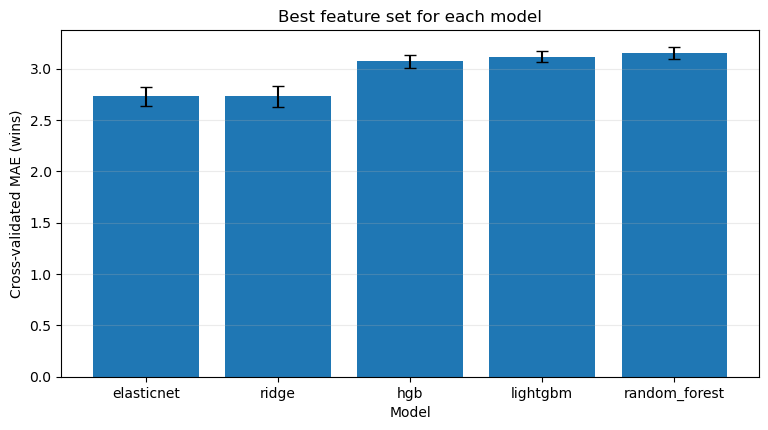

In [15]:
# A quick visual comparison of each model at its own best feature set.
# The error bars show fold-to-fold variation; a tiny difference in mean MAE
# is less convincing if one configuration is much less stable.

plot_data = best_by_model.copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    plot_data["model"],
    plot_data["mae_mean"],
    yerr=plot_data["mae_std"],
    capsize=4,
)
ax.set_ylabel("Cross-validated MAE (wins)")
ax.set_xlabel("Model")
ax.set_title("Best feature set for each model")
ax.grid(axis="y", alpha=0.25)
plt.show()

## 10. Inspect Ridge and ElasticNet coefficients

Both Ridge and ElasticNet performed best with `all_domain_raw`.

That result is worth inspecting because `all_domain_raw` contains both engineered
features and the original raw season totals. The raw columns could be adding useful
information, or the regularized models could simply be tolerating a large amount
of redundant information.

### Objective

Fit the best Ridge and ElasticNet configurations on the full training dataset and
inspect their standardized coefficients.

Because both pipelines standardize the inputs before fitting, coefficient magnitudes
are reasonably comparable across features.

### Important interpretation note

A large coefficient does **not** mean that a feature is independently causal or
uniquely important.

Many Moneyball features are correlated. For example:

- `raw_R`
- `core_R_pg`
- `core_RDiff_pg`
- `core_Pythag_win_pct`

all contain related information.

Regularized linear models may distribute predictive weight across correlated
features. We therefore use the coefficients as a **diagnostic**, not as a reason
to immediately delete low-weight features.

In [16]:
# ---------------------------------------------------------------------
# Fit the best Ridge and ElasticNet configurations for interpretation
# ---------------------------------------------------------------------
#
# This fit is NOT used to report validation performance.
# Performance was already measured using cross-validation above.
#
# We fit on all training rows here only so we can inspect the coefficient
# pattern learned from the complete dataset.

LINEAR_MODELS_TO_INSPECT = ["ridge", "elasticnet"]

coefficient_tables = {}

for model_name in LINEAR_MODELS_TO_INSPECT:

    # Find the best feature set already established by the CV benchmark.
    best_row = best_by_model.loc[
        best_by_model["model"] == model_name
    ].iloc[0]

    feature_set_name = best_row["feature_set"]
    features = FEATURE_SETS[feature_set_name]

    X = train_fe[features]
    y = train_fe[TARGET_COL].astype(float)

    # Reuse exactly the same model definition used during the benchmark.
    model = MODEL_FACTORIES[model_name]()

    model.fit(X, y)

    # Ridge and ElasticNet are inside the final "model" step of the pipeline.
    fitted_regressor = model.named_steps["model"]

    coef_table = pd.DataFrame(
        {
            "feature": features,
            "coefficient": fitted_regressor.coef_,
        }
    )

    coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

    # Identify the feature family to make the result easier to interpret.
    coef_table["family"] = (
        coef_table["feature"]
        .str.extract(r"^(season|core|bat|pitch|field|ctx|raw)_")[0]
        .fillna("other")
    )

    coef_table = coef_table.sort_values(
        "abs_coefficient",
        ascending=False,
    ).reset_index(drop=True)

    coefficient_tables[model_name] = coef_table

    print(
        f"\n{model_name.upper()} "
        f"— best feature set: {feature_set_name} "
        f"({len(features)} features)"
    )

    display(coef_table.head(20))


RIDGE — best feature set: all_domain_raw (72 features)


,feature,coefficient,abs_coefficient,family
0,bat_BB_rate_approx,-9.497134,9.497134,bat
1,raw_SV,9.017111,9.017111,raw
2,core_Pythag_win_pct,6.430978,6.430978,core
3,raw_BB,5.906290,5.906290,raw
4,bat_OBP_approx,5.847469,5.847469,bat
5,raw_HA,5.621010,5.621010,raw
6,raw_E,-5.451944,5.451944,raw
7,raw_SHO,5.417119,5.417119,raw
8,raw_AB,-5.002559,5.002559,raw
9,pitch_H9,-4.959946,4.959946,pitch



ELASTICNET — best feature set: all_domain_raw (72 features)


,feature,coefficient,abs_coefficient,family
0,core_Pythag_win_pct,5.155378,5.155378,core
1,raw_IPouts,4.181642,4.181642,raw
2,raw_AB,-3.455562,3.455562,raw
3,raw_SV,3.224348,3.224348,raw
4,raw_CG,1.952888,1.952888,raw
5,bat_AVG,1.832459,1.832459,bat
6,raw_R,1.653845,1.653845,raw
7,pitch_CG_pg,1.590779,1.590779,pitch
8,core_RDiff_pg,1.526243,1.526243,core
9,core_RDiff_adj,1.081853,1.081853,core


**Observation:** Both Ridge and ElasticNet benefit from retaining raw season totals alongside engineered rate features. ElasticNet concentrates much of that raw contribution in IPouts, AB, SV, CG, and R. Ridge spreads larger positive and negative coefficients across several strongly correlated raw/rate pairs, such as SV vs SV_pg and SHO vs SHO_pg.

**Interpretation:** The opposing Ridge coefficients are a sign of multicollinearity rather than evidence that the baseball relationship itself has reversed. Raw totals appear to retain season-volume and opportunity information that is not fully represented by the engineered rates.

**Decision:** Keep all_domain_raw intact for the shortlisted Ridge and ElasticNet configurations.

**Reasoning:** all_domain_raw improves cross-validated MAE substantially, and regularization is handling the correlated predictors. Individual coefficient magnitude is useful for understanding the model, but is not sufficient evidence to remove features. Any simplification should be validated through cross-validation.

## 11. Feature-family observations

The feature-set sequence also acts as a light, family-level ablation test.

A few examples of what to look for:

- `core` → `core_bat`: does batting add value?
- `core` → `core_pitch`: does pitching add value?
- `core_bat_pitch` → `core_bat_pitch_field`: does fielding help?
- `core_bat_pitch_field` → `all_domain`: does context help?
- `all_domain` → `all_domain_raw`: do raw totals still contribute after engineered features exist?

This is intentionally **family-level** analysis. I do not want to start deleting individual columns based on tiny CV fluctuations yet.

In [17]:
# Show feature sets in a logical progression rather than only by rank.
FEATURE_SET_ORDER = [
    "core",
    "core_bat",
    "core_pitch",
    "core_bat_pitch",
    "core_bat_pitch_field",
    "all_domain",
    "raw",
    "all_domain_raw",
]

family_view = (
    results
    .pivot(index="feature_set", columns="model", values="mae_mean")
    .reindex(FEATURE_SET_ORDER)
)

display(family_view.round(4))

model,elasticnet,hgb,lightgbm,random_forest,ridge
feature_set,,,,,
core,3.2025,3.3769,3.3567,3.4370,3.2028
core_bat,3.1830,3.4008,3.3239,3.4094,3.1858
core_pitch,2.9159,3.0724,3.1159,3.1538,2.9149
core_bat_pitch,2.8816,3.0799,3.1381,3.1816,2.8830
core_bat_pitch_field,2.8684,3.0796,3.1279,3.1754,2.8699
all_domain,2.8651,3.0809,3.1371,3.1793,2.8596
raw,2.8448,3.2261,3.2928,3.3487,2.8478
all_domain_raw,2.7278,3.0702,3.1208,3.1605,2.7293


## 12. Shortlist for the next stage

**Decision**

Keep the best configuration from each model family, rank those configurations, and carry the top **three model families** forward.

**Why three?**

- carrying only the single winner would make us overly dependent on this one screening CV;
- carrying every model forward wastes effort;
- keeping three preserves some model diversity, which matters later when we test cluster features and possible ensembles.

The shortlist stores the **model and its preferred feature set together**. We should not separate them after discovering that their performance is linked.

In [18]:
SHORTLIST_N_MODELS = 3

shortlist = (
    best_by_model
    .head(SHORTLIST_N_MODELS)
    .copy()
)

shortlist.to_csv(SHORTLIST_PATH, index=False)

print(f"Saved shortlist to: {SHORTLIST_PATH}")
display(
    shortlist[
        [
            "model",
            "feature_set",
            "n_features",
            "mae_mean",
            "mae_std",
        ]
    ].round(4)
)

Saved shortlist to: /home/shpang/devs/ntu/projects/baseball_v2/outputs/model_selection/03_model_shortlist.csv


,model,feature_set,n_features,mae_mean,mae_std
0,elasticnet,all_domain_raw,72,2.7278,0.0891
1,ridge,all_domain_raw,72,2.7293,0.1019
2,hgb,all_domain_raw,72,3.0702,0.0657


## 13. Observation, Decision & Reasoning

In [19]:
best = results.iloc[0]

print("OBSERVATION")
print(
    f"Best overall screening result: {best['model']} + "
    f"{best['feature_set']} ({int(best['n_features'])} features), "
    f"MAE {best['mae_mean']:.4f} ± {best['mae_std']:.4f}."
)

print("\nDECISION")
print(
    "Carry these model-specific configurations into the next experiment:"
)
for _, row in shortlist.iterrows():
    print(
        f"  - {row['model']} + {row['feature_set']} "
        f"({int(row['n_features'])} features, "
        f"MAE {row['mae_mean']:.4f})"
    )

print("\nREASONING")
print(
    "Feature selection is model-dependent, so each shortlisted model keeps "
    "the feature set on which it performed best. We are not tuning or "
    "ensembling yet; the goal here is to identify strong, stable candidates "
    "before adding more experimental complexity."
)

OBSERVATION
Best overall screening result: elasticnet + all_domain_raw (72 features), MAE 2.7278 ± 0.0891.

DECISION
Carry these model-specific configurations into the next experiment:
  - elasticnet + all_domain_raw (72 features, MAE 2.7278)
  - ridge + all_domain_raw (72 features, MAE 2.7293)
  - hgb + all_domain_raw (72 features, MAE 3.0702)

REASONING
Feature selection is model-dependent, so each shortlisted model keeps the feature set on which it performed best. We are not tuning or ensembling yet; the goal here is to identify strong, stable candidates before adding more experimental complexity.


### Observation

`all_domain_raw` produced the strongest results for both Ridge and ElasticNet, despite containing the largest number of features. This suggests that the original season totals retain useful information that is not fully represented by the engineered rate and efficiency features. The improvement is concentrated in the regularized linear models; HGB and Random Forest do not benefit similarly.

### Decision

Retain `all_domain_raw` as a candidate feature set rather than removing raw variables based on an assumption that they are redundant or noisy.

### Reasoning

Ridge and ElasticNet are designed to handle correlated predictors through regularization. The raw variables may provide useful scale/opportunity information alongside the engineered rate features. We will inspect which raw features contribute most before deciding whether the set can be simplified.